In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 500

data = pd.DataFrame({
    "timestamp": pd.date_range(start="2025-01-01", periods=n, freq="S"),
    "x": np.random.normal(0, 100, n),
    "y": np.random.normal(0, 100, n),
    "z": np.random.normal(50, 20, n),
    "velocity": np.random.normal(30, 5, n),
    "signal_strength": np.random.uniform(0.5, 1.0, n)
})

print(data.head())

            timestamp           x           y          z   velocity  \
0 2025-01-01 00:00:00   49.671415   92.617755  77.987109  33.891805   
1 2025-01-01 00:00:01  -13.826430  190.941664  68.492674  27.244071   
2 2025-01-01 00:00:02   64.768854 -139.856757  51.192607  25.909006   
3 2025-01-01 00:00:03  152.302986   56.296924  37.061264  29.983128   
4 2025-01-01 00:00:04  -23.415337  -65.064257  63.964466  29.149077   

   signal_strength  
0         0.703553  
1         0.533005  
2         0.674410  
3         0.555499  
4         0.904118  


C:\Users\JanMc\AppData\Local\Temp\ipykernel_46020\1182333467.py:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  "timestamp": pd.date_range(start="2025-01-01", periods=n, freq="S"),


In [2]:
data["distance"] = np.sqrt(data["x"]**2 + data["y"]**2 + data["z"]**2)

In [3]:
anomalies = data[data["signal_strength"] < 0.6]

print(anomalies.head())

             timestamp           x           y          z   velocity  \
1  2025-01-01 00:00:01  -13.826430  190.941664  68.492674  27.244071   
3  2025-01-01 00:00:03  152.302986   56.296924  37.061264  29.983128   
6  2025-01-01 00:00:06  157.921282  -59.239392  67.903864  33.481937   
10 2025-01-01 00:00:10  -46.341769   27.045683  76.347881  24.291554   
14 2025-01-01 00:00:14 -172.491783  -57.677133  84.719276  29.586597   

    signal_strength    distance  
1          0.533005  203.325197  
3          0.555499  166.550534  
6          0.536158  181.822363  
10         0.538431   93.316813  
14         0.525113  200.642525  


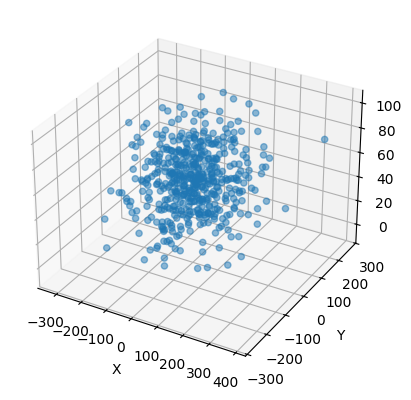

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(data["x"], data["y"], data["z"], alpha=0.5)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

plt.show()

In [5]:
data.groupby(pd.cut(data["distance"], bins=5))["signal_strength"].mean()

C:\Users\JanMc\AppData\Local\Temp\ipykernel_46020\637623614.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(pd.cut(data["distance"], bins=5))["signal_strength"].mean()


distance
(27.109, 107.901]     0.750161
(107.901, 188.292]    0.741793
(188.292, 268.682]    0.750070
(268.682, 349.073]    0.840534
(349.073, 429.463]    0.784370
Name: signal_strength, dtype: float64